In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score

In [2]:
df = pd.read_csv("Telco Customer Churn.csv")

print(df.head())
print(df.shape)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [4]:
# Convert TotalCharges from object/string into numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values
print(df.isnull().sum())

# Drop rows with missing TotalCharges
df = df.dropna()

# Remove customerID because it is only an ID and not useful for prediction
df = df.drop("customerID", axis=1)

print(df.shape)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
(7032, 20)


In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert target into numbers
# No = 0, Yes = 1
y = y.map({"No": 0, "Yes": 1})

In [6]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:")
print(categorical_cols)

print("Numerical columns:")
print(numerical_cols)

Categorical columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
Numerical columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)


In [9]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=50,
            random_state=42
        ))
    ]
)

In [10]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=50,
                                        random_state=42))])

In [11]:
y_pred = decision_tree_model.predict(X_test)
y_prob = decision_tree_model.predict_proba(X_test)[:, 1]

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))
print("AUC:", round(auc, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Accuracy: 0.793
Precision: 0.612
Recall: 0.607
F1-score: 0.609
AUC: 0.829

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1033
       Churn       0.61      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



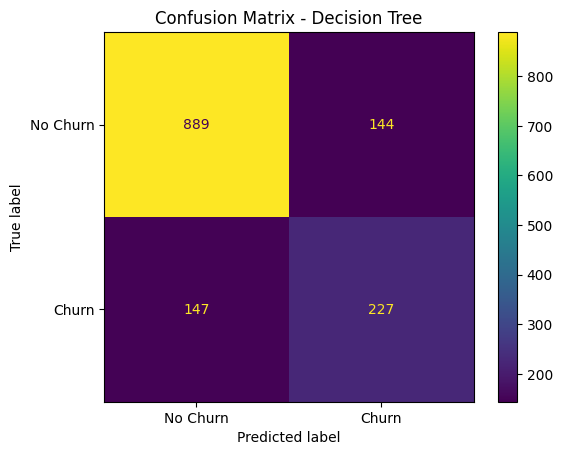

In [13]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 3))

Cross-validation scores: [0.79744136 0.80383795 0.7745377  0.78378378 0.80156472]
Mean CV Accuracy: 0.792


In [15]:
# Get feature names after one-hot encoding
encoded_cat_features = decision_tree_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_cols)

all_feature_names = list(encoded_cat_features) + list(numerical_cols)

# Get feature importance
importances = decision_tree_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(10))

                           Feature  Importance
32         Contract_Month-to-month    0.529176
12     InternetService_Fiber optic    0.153188
44                    TotalCharges    0.117783
42                          tenure    0.067153
43                  MonthlyCharges    0.040369
23                  TechSupport_No    0.028168
39  PaymentMethod_Electronic check    0.018465
33               Contract_One year    0.011992
31             StreamingMovies_Yes    0.010803
6                  PhoneService_No    0.008677


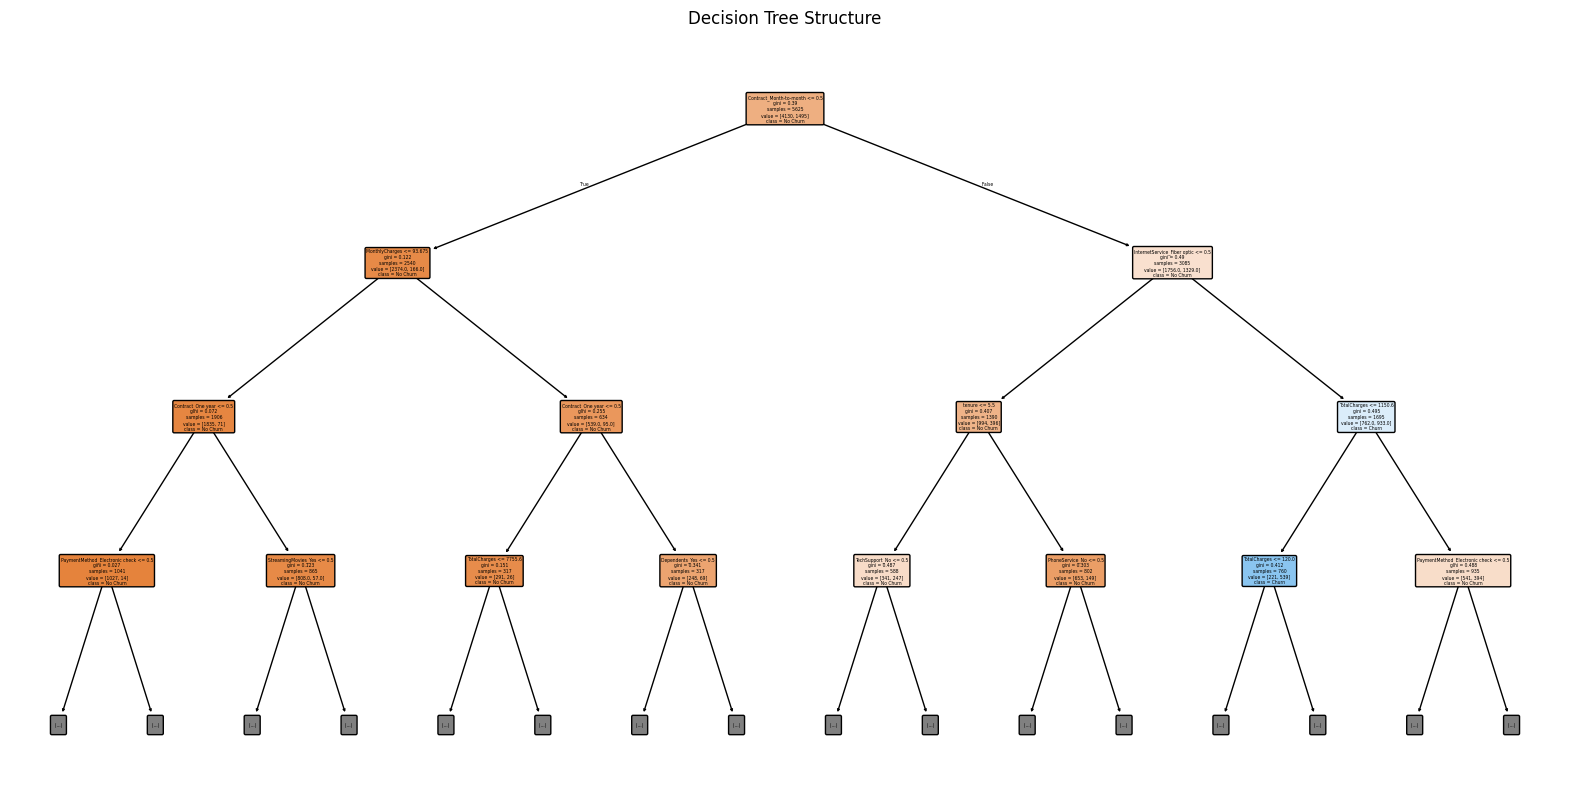

In [16]:
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model.named_steps["classifier"],
    feature_names=all_feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Structure")
plt.show()